SUBASRI R 24BAD116
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perime

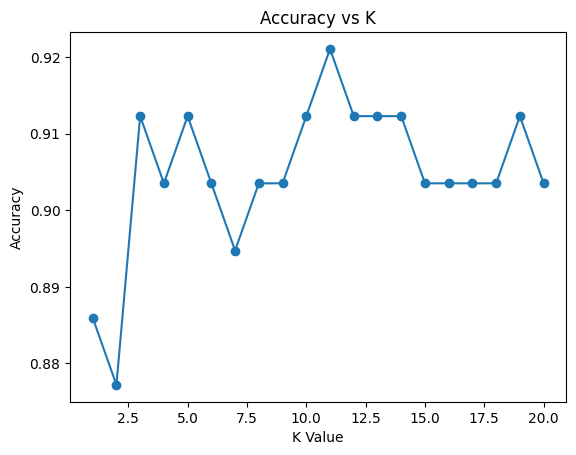

In [1]:
# EXPERIMENT 5 - KNN CLASSIFICATION
print("SUBASRI R 24BAD116")

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load Dataset
data = pd.read_csv('/content/breast-cancer.csv')
print(data.head())

# Features and Target
X = data[['radius_mean','texture_mean','perimeter_mean','area_mean','smoothness_mean']]
y = data['diagnosis']

# Encode Target
le = LabelEncoder()
y = le.fit_transform(y)

# Feature Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train Model
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print('Confusion Matrix')
print(confusion_matrix(y_test, y_pred))

# Accuracy vs K
acc = []
k_values = range(1,21)
for k in k_values:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    acc.append(accuracy_score(y_test, pred))

plt.plot(k_values, acc, marker='o')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('Accuracy vs K')
plt.show()


SUBASRI R 24BAD116
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2

/tmp/ipykernel_291/983160649.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  loan.fillna(method='ffill', inplace=True)


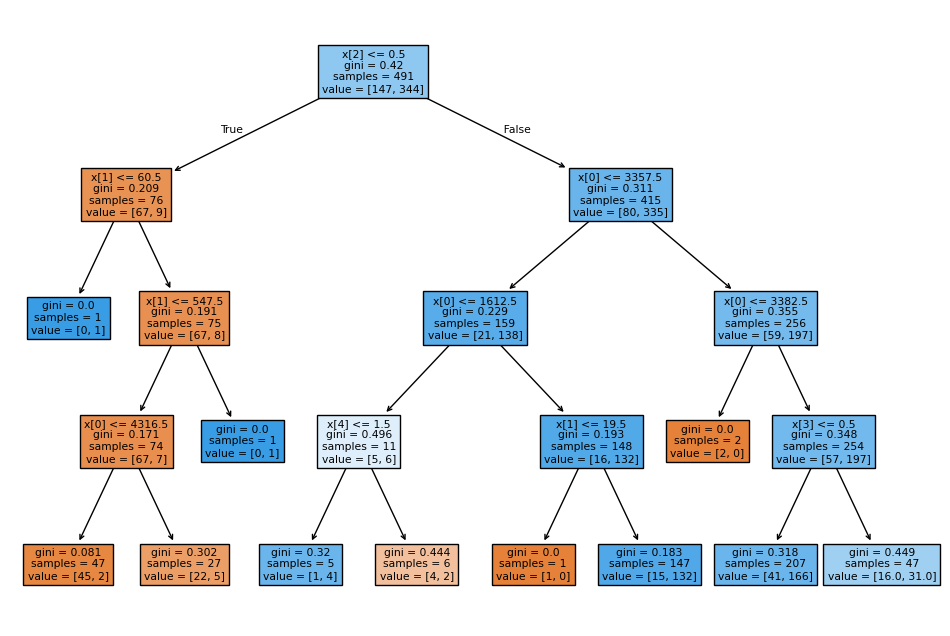

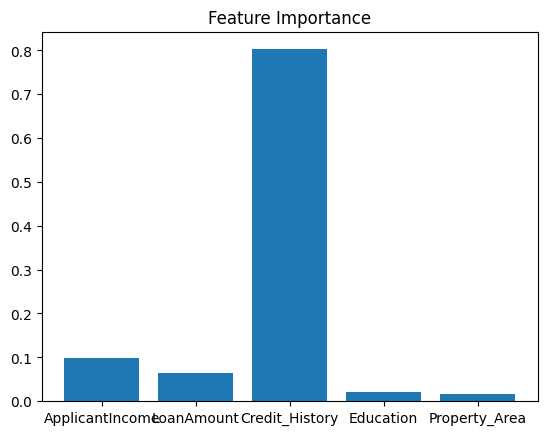

In [7]:
# DECISION TREE CLASSIFICATION
print("SUBASRI R 24BAD116")

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load Dataset
loan = pd.read_csv('/content/train_u6lujuX_CVtuZ9i (1).csv')
print(loan.head())

# Handle Missing Values
loan.fillna(method='ffill', inplace=True)

# Encode Categorical Variables
le = LabelEncoder()
for col in loan.columns:
    if loan[col].dtype == 'object':
        loan[col] = le.fit_transform(loan[col])

# Features and Target
X = loan[['ApplicantIncome','LoanAmount','Credit_History','Education','Property_Area']]
y = loan['Loan_Status']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train Model
dt = DecisionTreeClassifier(max_depth=4)
dt.fit(X_train, y_train)

# Prediction
y_pred = dt.predict(X_test)

# Evaluation
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print('Confusion Matrix')
print(confusion_matrix(y_test, y_pred))

# Tree Plot
plt.figure(figsize=(12,8))
plot_tree(dt, filled=True)
plt.show()

# Feature Importance
importance = dt.feature_importances_
features = X.columns
plt.bar(features, importance)
plt.title('Feature Importance')
plt.show()
